In [1]:
import sys
!{sys.executable} -m pip install segment-anything

from pathlib import Path
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, Subset
from tqdm.auto import tqdm
from segment_anything import sam_model_registry, SamPredictor

SEED = 42
IMAGE_SIZE = 256
FEWSHOT_N = 8

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

INPUT = Path("/kaggle/input")
WORK = Path("/kaggle/working")
PSEUDO_DIR = WORK / "b_prime"

if PSEUDO_DIR.exists():
    shutil.rmtree(PSEUDO_DIR)
PSEUDO_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda


In [2]:
def image_tensor(path):
    image = Image.open(path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BILINEAR)
    array = np.asarray(image, dtype=np.float32) / 255.0
    return torch.from_numpy(array).permute(2, 0, 1)

def mask_tensor(path):
    mask = Image.open(path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.NEAREST)
    array = np.asarray(mask, dtype=np.float32) / 255.0
    return (torch.from_numpy(array).unsqueeze(0) > 0.5).float()

def image_files(directory):
    extensions = {".jpg", ".jpeg", ".png"}
    return sorted(
        [p for p in directory.iterdir() if p.suffix.lower() in extensions],
        key=lambda p: int(p.stem) if p.stem.isdigit() else p.stem
    )

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, selected_ids=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.images = image_files(self.image_dir)
        if selected_ids is not None:
            selected_ids = {Path(x.strip()).stem for x in selected_ids}
            self.images = [p for p in self.images if p.stem in selected_ids]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_path = self.images[index]
        possible_masks = [
            self.mask_dir / image_path.name,
            self.mask_dir / f"{image_path.stem}.png",
            self.mask_dir / f"{image_path.stem}.jpg",
        ]
        mask_path = next((p for p in possible_masks if p.exists()), None)
        if mask_path is None:
            raise FileNotFoundError(f"No mask for {image_path}")
        return {
            "image": image_tensor(image_path),
            "mask": mask_tensor(mask_path),
            "sample_id": image_path.stem,
        }

In [3]:
CVC_ORIGINAL = next(INPUT.rglob("PNG/Original"))
CVC_MASKS = CVC_ORIGINAL.parent / "Ground Truth"
cvc_dataset = SegmentationDataset(CVC_ORIGINAL, CVC_MASKS)

cvc_indices = torch.randperm(len(cvc_dataset), generator=torch.Generator().manual_seed(SEED)).tolist()
cvc_train_indices = cvc_indices[:FEWSHOT_N]
cvc_train = Subset(cvc_dataset, cvc_train_indices)

KVASIR_IMAGES = next(path for path in INPUT.rglob("images") if (path.parent / "masks").exists())
KVASIR_MASKS = KVASIR_IMAGES.parent / "masks"
train_file = next(INPUT.rglob("train.txt"))
kvasir_train_ids = train_file.read_text().splitlines()
kvasir_train = SegmentationDataset(KVASIR_IMAGES, KVASIR_MASKS, kvasir_train_ids)

print(f"Dataset A Few-Shot Pool Size: {len(cvc_train)}")
print(f"Dataset B Unlabeled Input Target Size: {len(kvasir_train)}")

Dataset A Few-Shot Pool Size: 8
Dataset B Unlabeled Input Target Size: 880


In [4]:
MODEL_BASE_PATH = Path("/kaggle/input/models/mykcs01/sam_vit_b_01ec64.pth/pytorch/sam_vit_b_01ec64.pth/1")
try:
    SAM_CHECKPOINT = str(next(MODEL_BASE_PATH.rglob("*.pth")))
except StopIteration:
    SAM_CHECKPOINT = str(MODEL_BASE_PATH)

print(f"Loading checkpoint: {SAM_CHECKPOINT}")

model_type = "vit_b"
sam = sam_model_registry[model_type](checkpoint=SAM_CHECKPOINT).to(DEVICE)
predictor = SamPredictor(sam)

def get_center_prompt(image_size=256):
    input_point = np.array([[image_size // 2, image_size // 2]])
    input_label = np.array([1])
    return input_point, input_label

def binary_dice(prediction, target):
    intersection = (prediction * target).sum()
    return float((2 * intersection + 1e-6) / (prediction.sum() + target.sum() + 1e-6))

Loading checkpoint: /kaggle/input/models/mykcs01/sam_vit_b_01ec64.pth/pytorch/sam_vit_b_01ec64.pth/1/sam_vit_b_01ec64.pth


In [5]:
analysis_records = []

for batch in tqdm(kvasir_train, desc="Generating Clean Pseudo-Labels"):
    image_np = (batch["image"].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    target_np = batch["mask"].squeeze(0).numpy()
    sample_id = batch["sample_id"]
    
    predictor.set_image(image_np)
    points, labels = get_center_prompt(IMAGE_SIZE)
    
    masks, scores, logits = predictor.predict(
        point_coords=points,
        point_labels=labels,
        multimask_output=True
    )
    
    best_idx = np.argmax(scores)
    best_mask = masks[best_idx]
    best_score = scores[best_idx] 
    
    foreground_fraction = best_mask.mean()
    
    touches_top = np.any(best_mask[0, :])
    touches_bottom = np.any(best_mask[-1, :])
    touches_left = np.any(best_mask[:, 0])
    touches_right = np.any(best_mask[:, -1])
    edge_touch_count = sum([touches_top, touches_bottom, touches_left, touches_right])
    
    mask_img = Image.fromarray((best_mask * 255).astype(np.uint8))
    mask_img.save(PSEUDO_DIR / f"{sample_id}.png")

    analysis_records.append({
        "sample_id": sample_id,
        "confidence": best_score,
        "dice": binary_dice(best_mask.astype(np.float32), target_np),
        "foreground_fraction": foreground_fraction,
        "edge_touch_count": edge_touch_count
    })

print(f"Done! Generated feature logs for {len(analysis_records)} target samples.")
analysis_df = pd.DataFrame(analysis_records)

Generating Clean Pseudo-Labels:   0%|          | 0/880 [00:00<?, ?it/s]

Done! Generated feature logs for 880 target samples.


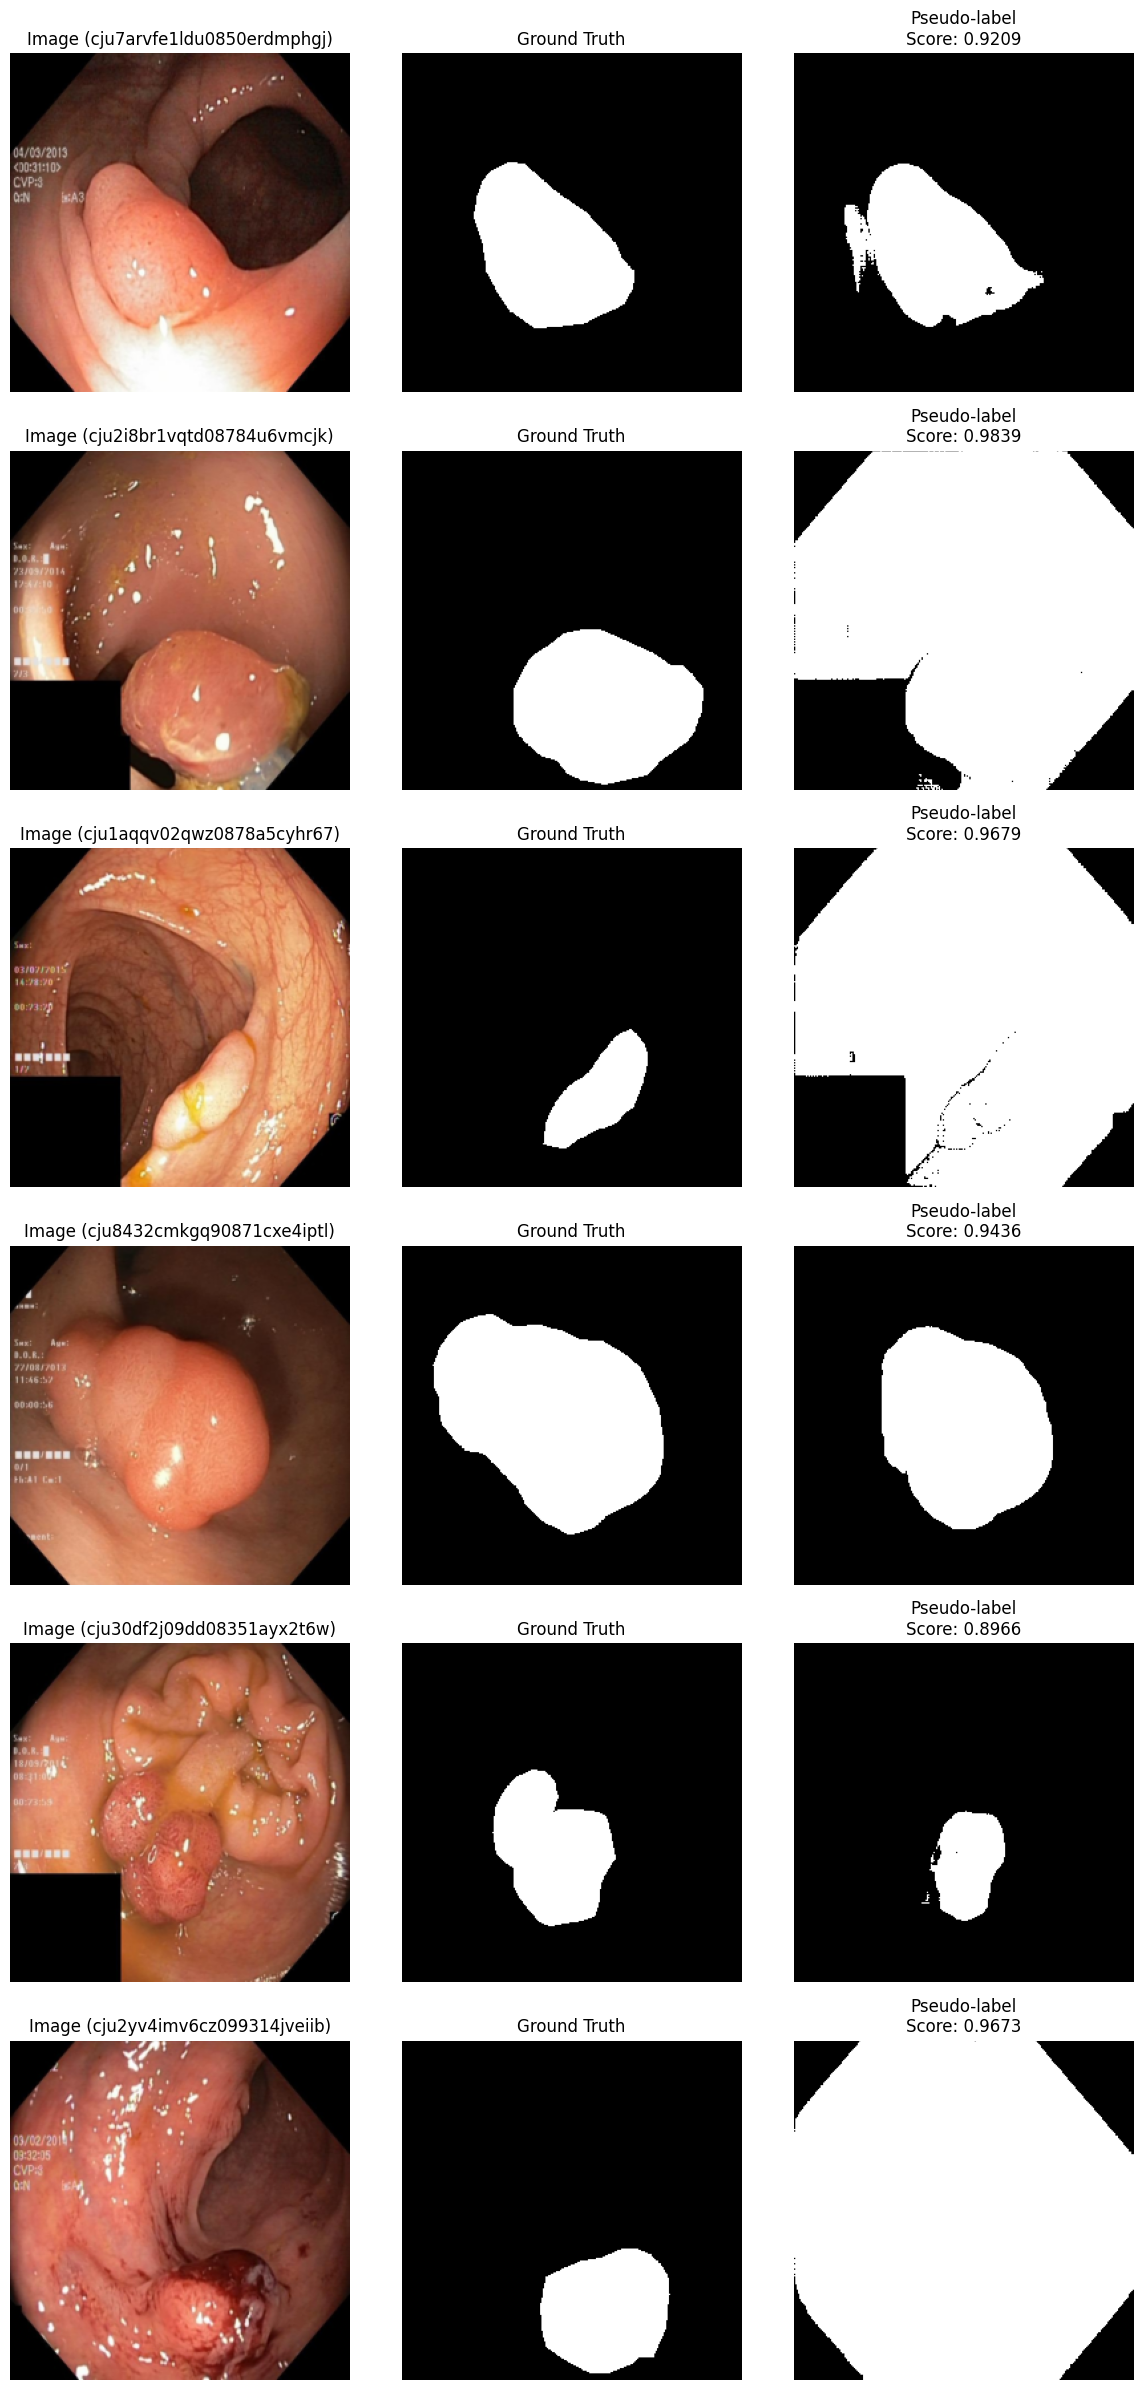

In [6]:
matching_samples = [batch for batch in kvasir_train if (PSEUDO_DIR / f"{batch['sample_id']}.png").exists()]
sampled_batches = random.sample(matching_samples, min(6, len(matching_samples)))

fig, axes = plt.subplots(len(sampled_batches), 3, figsize=(12, 4 * len(sampled_batches)))

for i, batch in enumerate(sampled_batches):
    image_np = (batch["image"].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    target_np = batch["mask"].squeeze(0).numpy()
    sample_id = batch["sample_id"]
    
    predictor.set_image(image_np)
    points, labels = get_center_prompt(IMAGE_SIZE)
    masks, scores, logits = predictor.predict(
        point_coords=points,
        point_labels=labels,
        multimask_output=True
    )
    
    best_idx = np.argmax(scores)
    best_mask = masks[best_idx]
    best_score = scores[best_idx]
    
    axes[i, 0].imshow(image_np)
    axes[i, 0].set_title(f"Image ({sample_id})")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(target_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(best_mask, cmap="gray")
    axes[i, 2].set_title(f"Pseudo-label\nScore: {best_score:.4f}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
confidence,880.0,0.944980,0.041902,7.176941e-01,0.927284,0.952945,0.971610,1.016547
dice,880.0,0.355424,0.324089,3.022426e-11,0.092145,0.234983,0.563716,0.989206
foreground_fraction,880.0,0.574934,0.340807,1.220703e-04,0.178833,0.778008,0.835552,0.932266
edge_touch_count,880.0,2.632955,1.767628,0.000000e+00,0.000000,4.000000,4.000000,4.000000


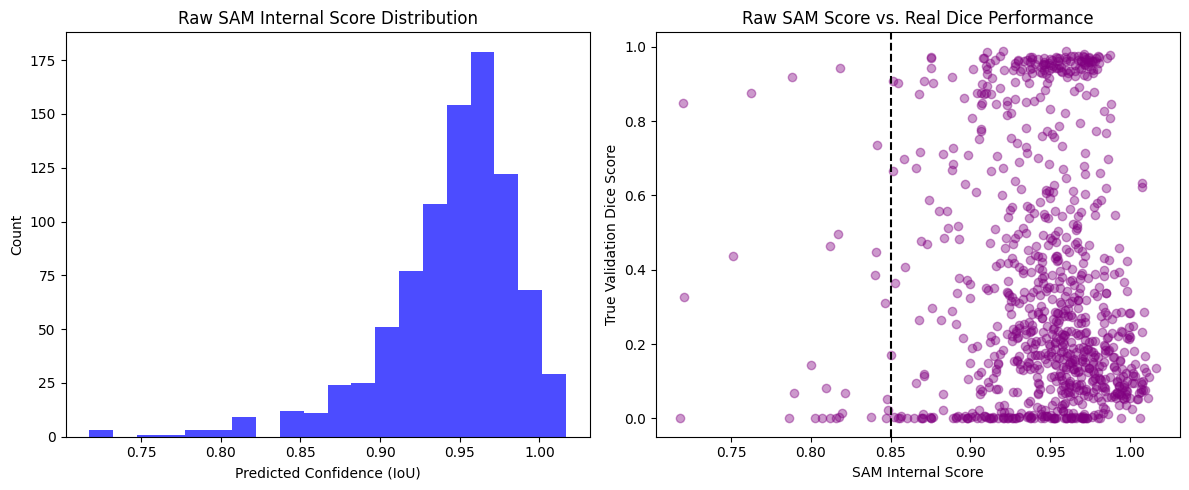

In [9]:
display(analysis_df[["confidence", "dice", "foreground_fraction", "edge_touch_count"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(analysis_df["confidence"], bins=20, alpha=0.7, color="blue")
axes[0].set_title("Raw SAM Internal Score Distribution")
axes[0].set_xlabel("Predicted Confidence (IoU)")
axes[0].set_ylabel("Count")

axes[1].scatter(analysis_df["confidence"], analysis_df["dice"], alpha=0.4, color="purple")
axes[1].set_title("Raw SAM Score vs. Real Dice Performance")
axes[1].set_xlabel("SAM Internal Score")
axes[1].set_ylabel("True Validation Dice Score")
axes[1].axvline(0.85, color="black", linestyle="--")

plt.tight_layout()
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

DICE_TARGET_THRESHOLD = 0.70
analysis_df["is_high_quality"] = (analysis_df["dice"] >= DICE_TARGET_THRESHOLD).astype(int)

features = ["confidence", "foreground_fraction", "edge_touch_count"]
X = analysis_df[features]
y = analysis_df["is_high_quality"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

calibrator = LogisticRegression(class_weight="balanced", random_state=SEED)
calibrator.fit(X_train, y_train)

weights = calibrator.coef_[0]
intercept = calibrator.intercept_[0]

print("=== CALIBRATION METRICS ===")
print(f"Calibration Validation Set Score: {calibrator.score(X_val, y_val):.4f}\n")
print("=== LEARNED LOGISTIC WEIGHTS ===")
for feat, coef in zip(features, weights):
    print(f"Feature: {feat:<20} | Coef: {coef:.4f}")
print(f"Model Intercept (Bias): {intercept:.4f}\n")

analysis_df["calibrated_score"] = calibrator.predict_proba(X)[:, 1]

PROBABILITY_THRESHOLD = 0.50
analysis_df["accepted_by_model"] = analysis_df["calibrated_score"] >= PROBABILITY_THRESHOLD

rejected_samples = analysis_df[analysis_df["accepted_by_model"] == False]
for _, row in rejected_samples.iterrows():
    file_path = PSEUDO_DIR / f"{row['sample_id']}.png"
    if file_path.exists():
        file_path.unlink()

final_count = analysis_df["accepted_by_model"].sum()
print(f"=== CLEANUP COMPLETE ===")
print(f"Kept {final_count} high-quality masks inside {PSEUDO_DIR}")
print(f"Deleted {len(rejected_samples)} low-probability background anomalies.\n")

print("=== TOP 10 ACCEPTED PSEUDO-LABELS ===")
display(analysis_df[analysis_df["accepted_by_model"] == True].sort_values(by="calibrated_score", ascending=False)[
    ["sample_id", "confidence", "dice", "foreground_fraction", "edge_touch_count", "calibrated_score"]
].head(10))

=== CALIBRATION METRICS ===
Calibration Validation Set Score: 0.8125

=== LEARNED LOGISTIC WEIGHTS ===
Feature: confidence           | Coef: 0.3379
Feature: foreground_fraction  | Coef: 0.3995
Feature: edge_touch_count     | Coef: -0.9384
Model Intercept (Bias): 1.2544

=== CLEANUP COMPLETE ===
Kept 281 high-quality masks inside /kaggle/working/b_prime
Deleted 599 low-probability background anomalies.

=== TOP 10 ACCEPTED PSEUDO-LABELS ===


,sample_id,confidence,dice,foreground_fraction,edge_touch_count,calibrated_score
212,cju2u2b9o4zvp08788qb9nqxj,0.868695,0.716694,0.422852,0,0.847722
13,cju17v6ih0u7808783zcbg1jy,0.946342,0.958866,0.325073,0,0.846058
726,cju7f5ghb2r5s0801chwkxxh9,0.985969,0.969167,0.280151,0,0.845463
185,cju2s16zp317h0799gr67jqc2,0.937663,0.958953,0.287415,0,0.843702
694,cju7dbppn28nx085097654msi,0.938858,0.972983,0.283295,0,0.843538
640,cju7adqyj1jcx08712r1ro5gx,0.954688,0.962513,0.258774,0,0.842950
504,cju5i5oh2efg60987ez6cpf72,0.918335,0.973855,0.287659,0,0.842852
338,cju35a77vdj4n08556jj2lgmc,0.954235,0.969699,0.256546,0,0.842812
790,cju88aq6vo1ij0755c2ey7z7n,0.949813,0.965885,0.240906,0,0.841784
750,cju83qd0yjyht0817ktkfl268,0.906389,0.773316,0.265320,0,0.841128


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Target definition setup
DICE_TARGET_THRESHOLD = 0.70
analysis_df["is_high_quality"] = (analysis_df["dice"] >= DICE_TARGET_THRESHOLD).astype(int)

# 2. Dataset-Level Split 
# 20% is isolated purely to optimize weights. 80% is the pristine Dataset B for the experiment.
calibration_df, experimental_b_df = train_test_split(
    analysis_df, 
    test_size=0.80, 
    random_state=SEED, 
    stratify=analysis_df["is_high_quality"]
)

features = ["confidence", "foreground_fraction", "edge_touch_count"]

# 3. Train the calibrator EXCLUSIVELY on the calibration partition
X_calib = calibration_df[features]
y_calib = calibration_df["is_high_quality"]

calibrator = LogisticRegression(class_weight="balanced", random_state=SEED)
calibrator.fit(X_calib, y_calib)

weights = calibrator.coef_[0]
intercept = calibrator.intercept_[0]

print("=== DATASET MINDSET SPLIT CONFIGURATION ===")
print(f"Isolated Calibration Pool Size : {len(calibration_df)} images (Ground-truth accessed)")
print(f"Pristine Dataset B Pool Size    : {len(experimental_b_df)} images (Blind application)\n")

print("=== LOCKED FROZEN FORMULA ===")
for feat, coef in zip(features, weights):
    print(f"Feature: {feat:<20} | Coef: {coef:.4f}")
print(f"Intercept Bias Coefficient   | Coef: {intercept:.4f}\n")

# 4. Apply the frozen formula blindly to the independent experimental partition
X_exp = experimental_b_df[features]
experimental_b_df = experimental_b_df.copy()  # Prevent slice copy warnings
experimental_b_df["calibrated_score"] = calibrator.predict_proba(X_exp)[:, 1]

PROBABILITY_THRESHOLD = 0.50
experimental_b_df["accepted_by_model"] = experimental_b_df["calibrated_score"] >= PROBABILITY_THRESHOLD

# 5. Rigorous Directory Cleanup
# Step A: Evict all calibration images from b_prime (They cannot participate in training)
for _, row in calibration_df.iterrows():
    file_path = PSEUDO_DIR / f"{row['sample_id']}.png"
    if file_path.exists():
        file_path.unlink()

# Step B: Evict experimental frames that failed to meet the frozen quality score
rejected_exp = experimental_b_df[experimental_b_df["accepted_by_model"] == False]
for _, row in rejected_exp.iterrows():
    file_path = PSEUDO_DIR / f"{row['sample_id']}.png"
    if file_path.exists():
        file_path.unlink()

final_b_prime_count = experimental_b_df["accepted_by_model"].sum()
print("=== EXPERIMENTAL DATA CLEANUP COMPLETE ===")
print(f"Successfully harvested {final_b_prime_count} pristine B' pseudo-labels into {PSEUDO_DIR}")
print(f"Purged {len(calibration_df)} calibration files and {len(rejected_exp)} low-scoring experimental files from disk.\n")

print("=== TOP 10 BLINDLY HARVESTED TARGET SAMPLES ===")
display(experimental_b_df[experimental_b_df["accepted_by_model"] == True].sort_values(by="calibrated_score", ascending=False)[
    ["sample_id", "confidence", "dice", "foreground_fraction", "edge_touch_count", "calibrated_score"]
].head(10))

=== DATASET MINDSET SPLIT CONFIGURATION ===
Isolated Calibration Pool Size : 176 images (Ground-truth accessed)
Pristine Dataset B Pool Size    : 704 images (Blind application)

=== LOCKED FROZEN FORMULA ===
Feature: confidence           | Coef: 0.3289
Feature: foreground_fraction  | Coef: 0.2400
Feature: edge_touch_count     | Coef: -0.8424
Intercept Bias Coefficient   | Coef: 1.1434

=== EXPERIMENTAL DATA CLEANUP COMPLETE ===
Successfully harvested 222 pristine B' pseudo-labels into /kaggle/working/b_prime
Purged 176 calibration files and 482 low-scoring experimental files from disk.

=== TOP 10 BLINDLY HARVESTED TARGET SAMPLES ===


,sample_id,confidence,dice,foreground_fraction,edge_touch_count,calibrated_score
726,cju7f5ghb2r5s0801chwkxxh9,0.985969,9.691674e-01,0.280151,0,0.822726
13,cju17v6ih0u7808783zcbg1jy,0.946342,9.588658e-01,0.325073,0,0.822398
212,cju2u2b9o4zvp08788qb9nqxj,0.868695,7.166942e-01,0.422852,0,0.822095
694,cju7dbppn28nx085097654msi,0.938858,9.729829e-01,0.283295,0,0.820566
640,cju7adqyj1jcx08712r1ro5gx,0.954688,9.625131e-01,0.258774,0,0.820466
504,cju5i5oh2efg60987ez6cpf72,0.918335,9.738547e-01,0.287659,0,0.819725
790,cju88aq6vo1ij0755c2ey7z7n,0.949813,9.658853e-01,0.240906,0,0.819596
337,cju358pwtdby20878cg7nm0np,0.964107,5.937890e-11,0.212234,0,0.819274
498,cju5hqz50e7o90850e0prlpa0,0.955258,9.415199e-01,0.223053,0,0.819227
840,cju8b3ka8r64u0801fh18hk7l,0.953835,6.051804e-11,0.217010,0,0.818943


In [12]:
# Compute the real validation performance metrics on the blindly accepted experimental subset
final_metrics = experimental_b_df[experimental_b_df["accepted_by_model"]]["dice"].describe()

print("=== COHORT QUALITY GATE: EXPERIMENTAL B' PSEUDO-LABELS ===")
print("This summary outlines the true, un-peeked quality of the targets being handed to Step 2.\n")
print(final_metrics)

=== COHORT QUALITY GATE: EXPERIMENTAL B' PSEUDO-LABELS ===
This summary outlines the true, un-peeked quality of the targets being handed to Step 2.

count    2.220000e+02
mean     5.214661e-01
std      4.382621e-01
min      3.546854e-11
25%      3.452933e-03
50%      7.375148e-01
75%      9.436460e-01
max      9.850952e-01
Name: dice, dtype: float64
